<a href="https://colab.research.google.com/github/karagoz-matias/Data-Science-WPO/blob/main/Exercise_session_8_2025_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#WPO 8: CRISP-DM

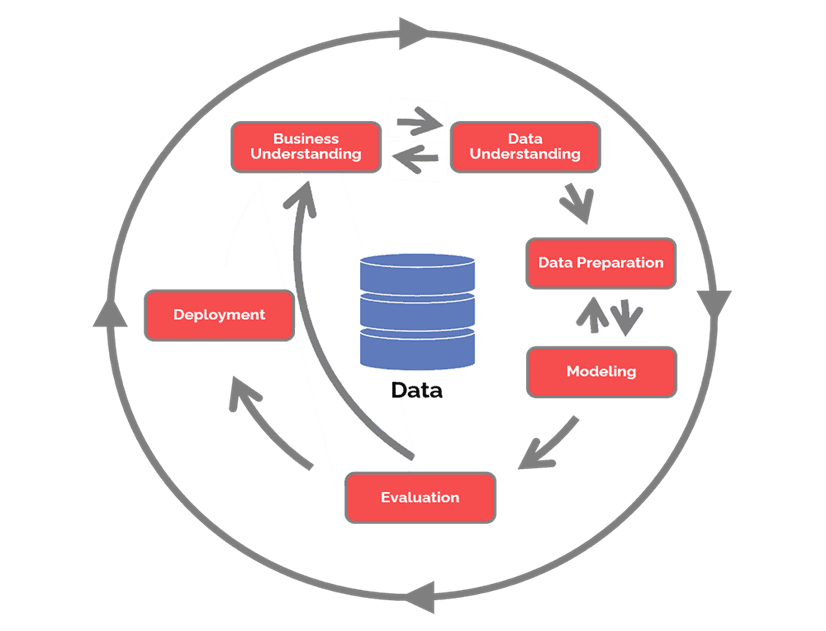

# Exercise 36: On-time delivery prediction

**META DATA**



1.  ID: ID Number of Customers.
2.  Warehouse block: The Company have big Warehouse which is divided in to block such as A,B,C,D,E.
3. Mode of shipment:The Company Ships the products in multiple way such as Ship, Flight and Road.
4. Customer care calls: The number of calls made from enquiry for enquiry of the shipment.
5. Customer rating: The company has rated from every customer. 1 is the lowest (Worst), 5 is the highest (Best).
6. Cost of the product: Cost of the Product in US Dollars.
7. Prior purchases: The Number of Prior Purchase.
8. Product importance: The company has categorized the product in the various parameter such as low, medium, high.
9. Gender: Male and Female.
10. Discount offered: Discount offered on that specific product.
11. Weight in gms: It is the weight in grams.
12. Reached on time: It is the target variable, where 1 Indicates that the product has NOT reached on time and 0 indicates it has reached on time.



## **Step 1:** Business Understanding

What do you know about this (business) data problem? Do you understand what the data is about? What is the meaning of each column? What is the target column? Which questions do you want to answer and why?

**Write answer here:**

On-time delivery service is a crucial factor in maintaining high customer retention rates and keeping customers satisfied. Furthermore, low OTD rates lead to more claims and costs for the business. It is therefore important to avoid late delivery (or false promises) and understand which factors might yield late delivery.

Do you understand what the data is about: 11 features about the satisfaction of the client, the importance and costs related to the product, and information about the warehouse and shipment mode.

The target column has the name “Reached.on.Time_Y.N” and contains two classes: 0 (=yes) and 1(=no) indicating whether or not a certain product was delivered on time or not.

Which questions do you want to answer? => We want to enable the identification/prediction of not-on-time delivered products as they would need more care => Additionally, it would be interesting to understand which type of products/shipments yield not-on-time delivered products


## **Step 2:** Data Understanding

What kind of data do we have? Which features does the data contain? What is the target column? Explore the data with “dataframe” methods and matplotlib-visualization techniques.

**Pandas DataFrame methods**

In [3]:
import pandas as pd
OTD=pd.read_csv('/content/On_Time_Delivery.csv')

In [ ]:
OTD.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
OTD.nunique()

,0
ID,10999
Warehouse_block,5
Mode_of_Shipment,3
Customer_care_calls,6
Customer_rating,5
Cost_of_the_Product,215
Prior_purchases,8
Product_importance,3
Gender,2
Discount_offered,65


In [5]:
OTD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [6]:
OTD.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [7]:
OTD=OTD.drop(["ID"], axis=1)

**Matplotlib visualization methods**

In [ ]:
# Pie charts & scatter plots

/tmp/ipython-input-2027318022.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Ontime=OTD[OTD['Reached.on.Time_Y.N']==1].count()[0]
/tmp/ipython-input-2027318022.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Late=OTD[OTD['Reached.on.Time_Y.N']==0].count()[0]


([<matplotlib.patches.Wedge at 0x7d44adb86870>,
 [Text(-0.32902379458151726, 1.0496396251091036, 'Ontime'),
  Text(0.3290242617242808, -1.0496394786767467, 'Late')])

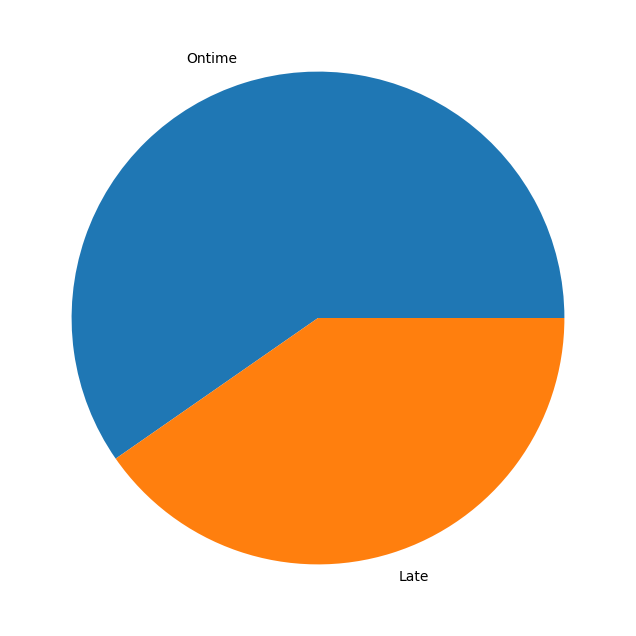

In [8]:
import matplotlib.pyplot as plt

fig, ax=plt.subplots(figsize=(10,8))

Ontime=OTD[OTD['Reached.on.Time_Y.N']==1].count()[0]
Late=OTD[OTD['Reached.on.Time_Y.N']==0].count()[0]

ax.pie([Ontime, Late], labels=["Ontime", "Late"])


Text(0, 0.5, 'Cost of the Product')

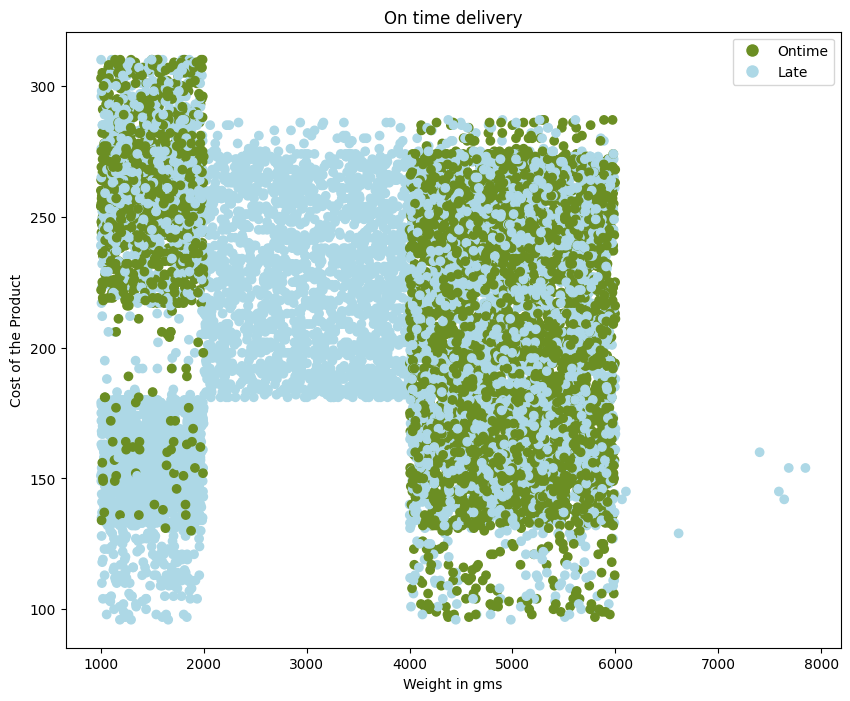

In [9]:
fig, ax=plt.subplots(figsize=(10,8))
colors=["olivedrab", "lightblue"]
color_map=[colors[c] for c in OTD['Reached.on.Time_Y.N']]
ax.scatter(OTD['Weight_in_gms'], OTD['Cost_of_the_Product'], c=color_map)
labels=["Ontime", "Late"]
ax.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for color, label in zip(colors, labels)])
plt.title("On time delivery")
plt.xlabel("Weight in gms")
plt.ylabel("Cost of the Product")

## **Step 3:** Data Preparation

Data is not always “clean” enough to be used by a machine learning algorithm:
  

1.   Missing values (A)
2.   Categories might be encoded as words instead of numbers (B)
3.   Features might be at different scales (C)

Remember that not all these steps are necessary for all models.

**A) Missing Values**

In [10]:
OTD

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...
10994,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,C,Ship,5,4,242,5,low,F,4,1155,0
10997,F,Ship,5,2,223,6,medium,M,2,1210,0


In [11]:
OTD.isna().sum()

,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0
Weight_in_gms,0


In [12]:
OTD.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


In [13]:
OTD.nunique()

,0
Warehouse_block,5
Mode_of_Shipment,3
Customer_care_calls,6
Customer_rating,5
Cost_of_the_Product,215
Prior_purchases,8
Product_importance,3
Gender,2
Discount_offered,65
Weight_in_gms,4034


In [14]:
OTD.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


**B) Encode Categorical Features**

In [15]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
OE=OrdinalEncoder()
Ordinal_columns=["Gender", "Product_importance"]
OTD[Ordinal_columns]=OE.fit_transform(OTD[Ordinal_columns])

OHE=OneHotEncoder(drop='first', sparse_output=False, feature_name_combiner='concat')
OHE_columns=['Warehouse_block', 'Mode_of_Shipment']
OHE_encoded=pd.DataFrame(OHE.fit_transform((OTD[OHE_columns])), columns=OHE.get_feature_names_out())
OTD=pd.concat([OTD.drop(OHE_columns, axis=1), OHE_encoded], axis=1)

In [16]:
OTD

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship
0,4,2,177,3,1.0,0.0,44,1233,1,0.0,0.0,1.0,0.0,0.0,0.0
1,4,5,216,2,1.0,1.0,59,3088,1,0.0,0.0,0.0,1.0,0.0,0.0
2,2,2,183,4,1.0,1.0,48,3374,1,0.0,0.0,0.0,0.0,0.0,0.0
3,3,3,176,4,2.0,1.0,10,1177,1,1.0,0.0,0.0,0.0,0.0,0.0
4,2,2,184,3,2.0,0.0,46,2484,1,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,4,1,252,5,2.0,0.0,1,1538,1,0.0,0.0,0.0,0.0,0.0,1.0
10995,4,1,232,5,2.0,0.0,6,1247,0,1.0,0.0,0.0,0.0,0.0,1.0
10996,5,4,242,5,1.0,0.0,4,1155,0,0.0,1.0,0.0,0.0,0.0,1.0
10997,5,2,223,6,2.0,1.0,2,1210,0,0.0,0.0,0.0,1.0,0.0,1.0


**C) Scale Features**

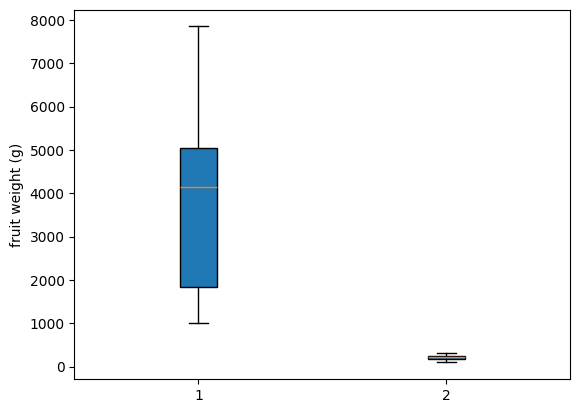

In [17]:

fig, ax = plt.subplots()
ax.set_ylabel('fruit weight (g)')

bplot = ax.boxplot(OTD[["Weight_in_gms", "Cost_of_the_Product"]],
                   patch_artist=True,  # fill with color
                 )  # will be used to label x-ticks


!! Split data first to avoid data leakage!

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(OTD.drop("Reached.on.Time_Y.N", axis=1), OTD["Reached.on.Time_Y.N"], test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## **Step 4:** Modeling

We saw many types of models during the previous exercise sessions. Which models are convenient for this data problem and why?

Interpretable? Very complex? Data Imbalance?     DT, Bagging, Stacking?

**Write answer here:**

In [ ]:
#Given our problem: a binary classification with interpretable business needs — logistic regression and decision trees help provide explanations, while Random Forest and Gradient Boosting offer higher predictive power. Training (“fitting”) these models allows them to learn patterns in the data that differentiate on-time and late deliveries, enabling better decision-making and proactive management of high-risk shipments.

**Optimize the different Models through cross-validation Grid Search**

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

Model A= Logistic Regression

Default Param?

In [21]:
from sklearn.linear_model import LogisticRegression

LR2=LogisticRegression(random_state=42)
LR2.fit(X_train_scaled, y_train)
print(roc_auc_score(y_train, LR2.predict_proba(X_train_scaled)[:, 1]))

0.7218760745315782


Hyperparameter tuning!

In [22]:
C=[0.1, 0.2, 0.4, 0.6, 0.8, 0.9,1]
paramlr=dict( C=C)
Grid_LR=GridSearchCV(LogisticRegression(random_state=42), param_grid=paramlr, verbose=2, cv=5, return_train_score=True)
Grid_LR.fit(X_train_scaled, y_train)
Best_LR=Grid_LR.best_estimator_
print(roc_auc_score(y_train, Best_LR.predict_proba(X_train_scaled)[:, 1]))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.2; total time=   0.0s
[CV] END ..............................................C=0.2; total time=   0.0s
[CV] END ..............................................C=0.2; total time=   0.0s
[CV] END ..............................................C=0.2; total time=   0.0s
[CV] END ..............................................C=0.2; total time=   0.0s
[CV] END ..............................................C=0.4; total time=   0.0s
[CV] END ........................................

In [23]:
Grid_LR.best_score_

np.float64(0.6378015013695798)

Model B= Decision Tree

Your turn! Given the example for Logistic Regression and the parameter grid below, tune the decision tree.

In [24]:
from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier(random_state = 42)

max_depth=[5, 10, 15, 20, 25, 30, 40, 50,  None]
max_leaf_nodes=[100, 200, 300,  400, 450,500, 1000, None]
parameters=dict(max_depth=max_depth, max_leaf_nodes=max_leaf_nodes)

Grid_DT = GridSearchCV(DecisionTreeClassifier(random_state = 42), param_grid = parameters, cv =5)

Grid_DT.fit(X_train, y_train)
Best_DT = Grid_DT.best_estimator_

In [25]:
Grid_DT.best_estimator_

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=100, random_state=42)

In [26]:
Grid_DT.best_score_

np.float64(0.679738100160215)

Model C= Random Forests

In [27]:
from sklearn.ensemble import RandomForestClassifier
n_estimators = [10, 100, 500, 1000, 700]
parameters = dict(max_depth = max_depth, n_estimators = n_estimators)
Grid_RF = GridSearchCV(RandomForestClassifier(random_state =42), param_grid = parameters, verbose =2, cv = 5 )
Grid_RF.fit(X_train, y_train)
Best_RF = Grid_RF.best_estimator_


Fitting 5 folds for each of 45 candidates, totalling 225 fits
[CV] END .......................max_depth=5, n_estimators=10; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=10; total time=   0.1s
[CV] END .......................max_depth=5, n_estimators=10; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=10; total time=   0.0s
[CV] END .......................max_depth=5, n_estimators=10; total time=   0.0s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=100; total time=   0.4s
[CV] END ......................max_depth=5, n_estimators=500; total time=   2.0s
[CV] END ......................max_depth=5, n_e

In [28]:
Grid_RF.best_score_

np.float64(0.6757600521990801)

Model D=

In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
# Define the hyperparameters grid to search for the AdaBoostClassifier
n_estimators = [50, 100, 200, 300, 400, 500]
learning_rate = [0.01, 0.1, 1, 10, 100]
parameters = dict(n_estimators=n_estimators, learning_rate=learning_rate)

# Initialize the GridSearchCV object for AdaBoostClassifier
Grid_AB = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid=parameters, verbose=2, cv=5)

# Fit GridSearchCV to the training data
Grid_AB.fit(X_train, y_train)

# Get the best estimator and its parameters
Best_AB = Grid_AB.best_estimator_
best_params_ab = Grid_AB.best_params_

# Compute the ROC AUC score on the training set using predicted probabilities from the best AdaBoost model
print(roc_auc_score(y_train, Best_AB.predict_proba(X_train)[:, 1]))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.3s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.3s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.3s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.3s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.3s
[CV] END ...............learning_rate=0.01, n_estimators=100; total time=   0.6s
[CV] END ...............learning_rate=0.01, n_estimators=100; total time=   0.6s
[CV] END ...............learning_rate=0.01, n_estimators=100; total time=   0.6s
[CV] END ...............learning_rate=0.01, n_estimators=100; total time=   0.6s
[CV] END ...............learning_rate=0.01, n_estimators=100; total time=   0.6s
[CV] END ...............learning_rate=0.01, n_estimators=200; total time=   1.2s
[CV] END ...............learning_rate=0.01, n_e

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packa

[CV] END ................learning_rate=100, n_estimators=200; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=200; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=200; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=200; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=200; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=300; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=300; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=300; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=300; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=300; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=400; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=400; total time=   0.0s


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packa

[CV] END ................learning_rate=100, n_estimators=400; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=400; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=400; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=500; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=500; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=500; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=500; total time=   0.0s
[CV] END ................learning_rate=100, n_estimators=500; total time=   0.0s


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packa

0.7515012693235757


In [30]:
from sklearn.metrics import roc_auc_score
train_roc_auc_ab = roc_auc_score(y_train, Best_AB.predict_proba(X_train)[:, 1])

print(f"Best parameters from GridSearchCV for AdaBoostClassifier: {best_params_ab}")
print(f"ROC AUC on training data with best AdaBoostClassifier: {train_roc_auc_ab}")

Best parameters from GridSearchCV for AdaBoostClassifier: {'learning_rate': 1, 'n_estimators': 400}
ROC AUC on training data with best AdaBoostClassifier: 0.7515012693235757


## **Step 5:** Evaluation

Which evaluation metric(s) do you want to use to compare the generalization perofrmance and why?

In [31]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

**Write answer here:**

Model A

In [32]:
print(roc_auc_score(y_test, Grid_LR.best_estimator_.predict(X_test_scaled)))
print(confusion_matrix(y_test, Grid_LR.best_estimator_.predict(X_test_scaled)))

0.6219867719771399
[[492 403]
 [399 906]]


Model B

In [33]:
print(roc_auc_score(y_test, Best_DT.predict(X_test)))
print(confusion_matrix(y_test, Best_DT.predict(X_test)))
print(accuracy_score(y_test, Best_DT.predict(X_test)))

0.7225475716517905
[[827  68]
 [625 680]]
0.685


Model C

In [34]:
print(roc_auc_score(y_test, Best_RF.predict(X_test)))
print(confusion_matrix(y_test, Best_RF.predict(X_test)))
print(accuracy_score(y_test, Best_RF.predict(X_test)))

0.7187182944840429
[[803  92]
 [600 705]]
0.6854545454545454


np.float64(0.6219867719771399)

Model D

In [35]:
print(roc_auc_score(y_test, Best_AB.predict(X_test)))
print(confusion_matrix(y_test, Best_AB.predict(X_test)))
print(accuracy_score(y_test, Best_AB.predict(X_test)))

0.6991523791177038
[[733 162]
 [549 756]]
0.6768181818181818


## **Step 6:** Deployment

What is the final output of the process? What are the results and conclusions?

**Write answer here:**

The e-commerce company should not fully deploy the model for automatic decision-making.
Instead, they should:
Use the model as a risk-scoring/flagging aid, not a deterministic classifier.
Improve data quality and collect additional predictive features.
Iterate on the CRISP-DM cycle, especially data understanding and modeling.
Run a monitored pilot phase before considering full deployment.

# EXTRA: Exercise 37: House Price Prediction

Apply every step of the Cross Industry Standard Process for Data Mining to the house pricing dataset.

## **Step 1:** Business Understanding

## **Step 2:** Data Understanding

## **Step 3:** Data Preparation

## **Step 4:** Modeling

## **Step 5:** Evaluation

## **Step 6:** Deployment